### Plotting for the paper

In [1]:
import ast
import gzip
import numpy as np
import pandas as pd
import seaborn as sns
from Bio import SeqIO
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

delta_df = pd.read_csv("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/6-ism_variant_effects/delta_ism_OT_all.csv")

predictions = pd.read_csv(
    "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/2-opentargets_model_variant_effect/gosai/k562_gosai_ref_alt_with_seq.csv.gz",
    compression="gzip"
)

predictions["offset_0"] = predictions["offset_0"].apply(ast.literal_eval)

predictions["ref"] = predictions["offset_0"].apply(lambda x: x["ref"])
predictions["alt"] = predictions["offset_0"].apply(lambda x: x["alt"])

predictions["variant_effect"] = predictions["ref"] - predictions["alt"]
predictions["ref_seq"] = predictions["offset_0"].apply(lambda x: x["ref_seq"])
predictions["alt_seq"] = predictions["offset_0"].apply(lambda x: x["alt_seq"])

filtered_variants = predictions[
    (predictions["variant_effect"] > 0.5) | (predictions["variant_effect"] < -0.5)
]

print(filtered_variants.shape)
print(delta_df.shape)

(2956, 6)
(2956, 7)


In [2]:
import ast 

delta_df["ism"] = delta_df["ism"].apply(
    lambda x: np.array(ast.literal_eval(x), dtype=float)
)

filtered_variants["variant_effect"] = filtered_variants["variant_effect"].astype(float)

delta_df["ism_scaled"] = [
    ism / ve if ve != 0 else np.zeros_like(ism)
    for ism, ve in zip(delta_df["ism"], filtered_variants["variant_effect"])
]

print(delta_df["ism_scaled"].head(5))

0    [0.012130224179491758, 0.01248827494646467, -0...
1    [0.02331111809410077, -0.05131290664048528, -0...
2    [-0.0034723781662645407, 2.06234378289384e-05,...
3    [-0.007012580129761172, -0.014264399153087845,...
4    [-0.013192904790065336, -0.008835330028309132,...
Name: ism_scaled, dtype: object


/tmp/ipykernel_1306780/298968781.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_variants["variant_effect"] = filtered_variants["variant_effect"].astype(float)


### First plot a high vs low

In [3]:
# Compute average ISM per sequence
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
import ast

# --- Average numeric entries from dicts ---
def avg_numeric_dicts(dict_list):
    vals = []
    for d in dict_list:
        nums = [v for k, v in d.items() if isinstance(v, (int, float))]
        vals.append(np.mean(nums) if nums else np.nan)
    return np.array(vals)

# Apply across all rows
delta_df["ism_predictions_ref"] = delta_df["ism_predictions_ref"].apply(
    lambda x: np.array(ast.literal_eval(x), dtype=dict)
)
# Apply across all rows
delta_df["ism_predictions_alt"] = delta_df["ism_predictions_alt"].apply(
    lambda x: np.array(ast.literal_eval(x), dtype=dict)
)

ism_alt_avg = delta_df["ism_predictions_alt"].apply(avg_numeric_dicts)
ism_ref_avg = delta_df["ism_predictions_ref"].apply(avg_numeric_dicts)

# Variant effect
variant_effect = filtered_variants["variant_effect"].values

# Initialize lists
high_rows = []
low_rows = []

for i, effect in enumerate(variant_effect):
    if effect > 0:
        # high effect → take ref ISM
        high_rows.append(ism_ref_avg.iloc[i])
        # low effect → take alt ISM
        low_rows.append(ism_alt_avg.iloc[i])
    else:
        # effect < 0 → flip
        high_rows.append(ism_alt_avg.iloc[i])
        low_rows.append(ism_ref_avg.iloc[i])

# Convert to arrays for heatmaps
high_array = np.vstack(high_rows)
low_array  = np.vstack(low_rows)


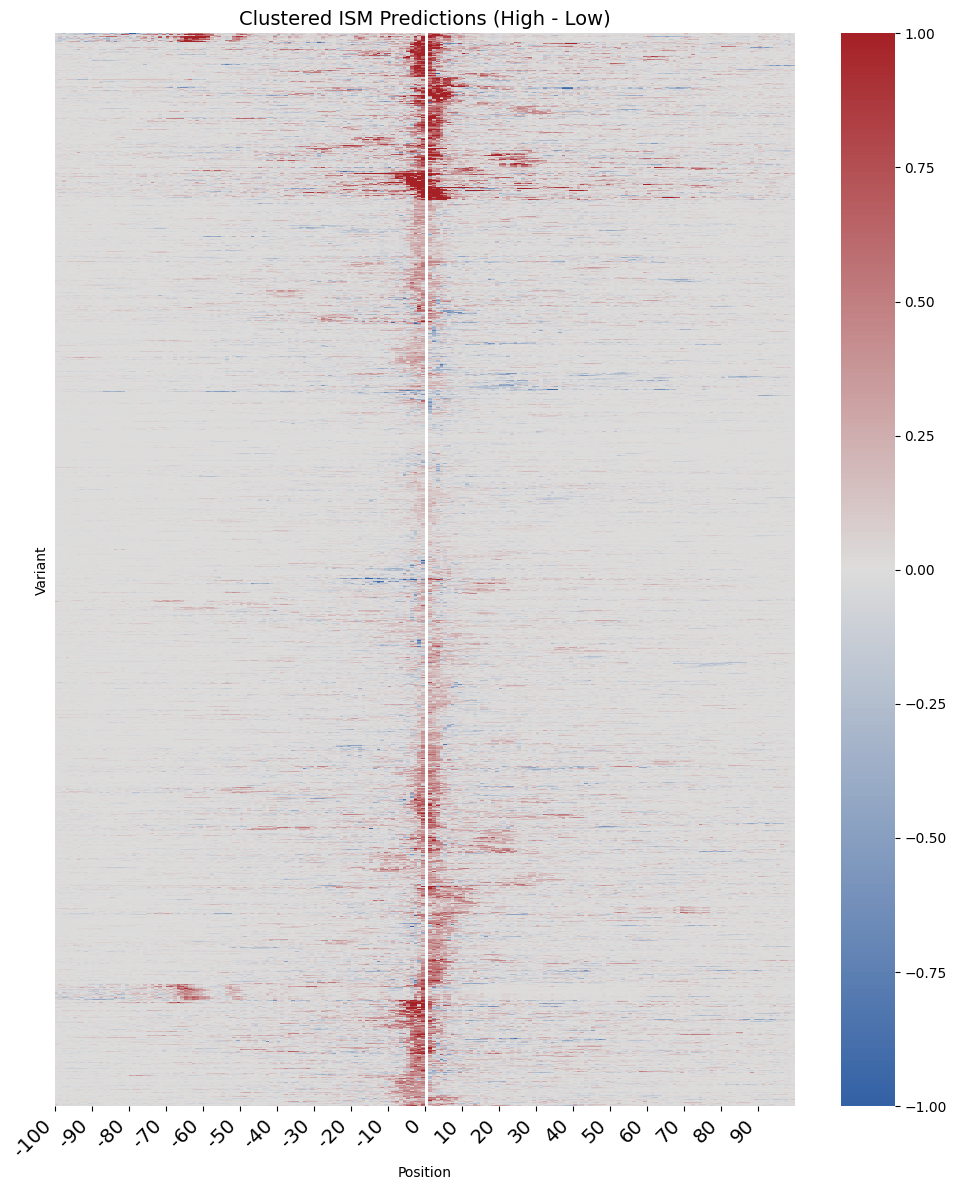

In [4]:
diff_array = high_array - low_array

from scipy.cluster.hierarchy import linkage, leaves_list

row_labels = delta_df.index.astype(str).tolist()
row_linkage = linkage(diff_array, method='ward', metric='euclidean')
row_order = leaves_list(row_linkage)

# Reorder diff_array and row labels according to clustering
heatmap_array = diff_array[row_order]

# --- Mask the 99th position (0-based = 100th) ---
mask = np.zeros_like(heatmap_array, dtype=bool)
if heatmap_array.shape[1] > 99:
    mask[:, 100] = True

# --- Shared color scale ---
heatmap_array = np.clip(heatmap_array, -1, 1)
vmin, vmax = -1, 1
# vmin = np.min(diff_array)
# vmax = np.max(diff_array)

coolwarm = plt.cm.coolwarm
mid_grey = coolwarm(0.5)
white_pos = abs(vmin) / (vmax - vmin)  # normalize position of white center (usually 0)
colors = [
    (0, "#3361A5"),        # dark blue at min
    (white_pos, mid_grey), # white at 0
    (1.0, "#A52126")        # dark red at max
]
custom_cmap = LinearSegmentedColormap.from_list("blue_white_red", colors)

# --- Plot ---
plt.figure(figsize=(10, 12))
sns.heatmap(
    heatmap_array,
    cmap=custom_cmap,
    center=0,
    vmin=vmin,
    vmax=vmax,
    xticklabels=10,
    yticklabels="",
    mask=mask,
    cbar=True
)

plt.title("Clustered ISM Predictions (High - Low)", fontsize=14)
plt.xlabel("Position")
plt.ylabel("Variant")
tick_positions = np.arange(0, 200, 10)
tick_labels    = np.arange(-100, 100, 10)

plt.xticks(tick_positions, tick_labels, rotation=45, ha="right", fontsize=14)
plt.tight_layout()
plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/6-ism_variant_effects/delta_ism.png", dpi=1200)
plt.show()


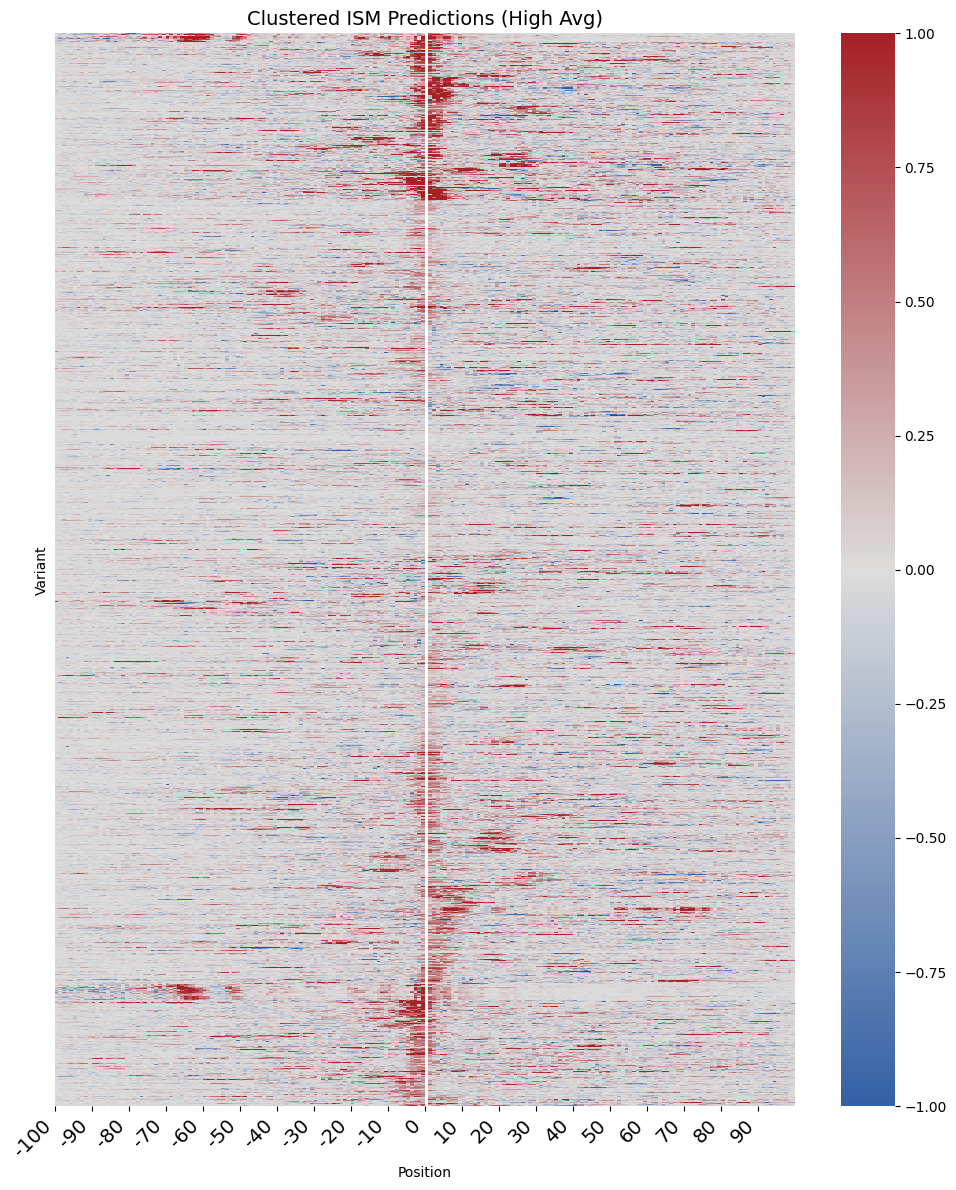

In [5]:
heatmap_array = high_array[row_order]

# --- Mask the 99th position (0-based = 100th) ---
mask = np.zeros_like(heatmap_array, dtype=bool)
if heatmap_array.shape[1] > 99:
    mask[:, 100] = True

# --- Shared color scale ---
heatmap_array = np.clip(heatmap_array, -1, 1)
vmin, vmax = -1, 1

coolwarm = plt.cm.coolwarm
mid_grey = coolwarm(0.5)
white_pos = abs(vmin) / (vmax - vmin)  # normalize position of white center (usually 0)
colors = [
    (0, "#3361A5"),        # dark blue at min
    (white_pos, mid_grey), # white at 0
    (1.0, "#A52126")        # dark red at max
]
custom_cmap = LinearSegmentedColormap.from_list("blue_white_red", colors)

# --- Plot ---
plt.figure(figsize=(10, 12))
sns.heatmap(
    heatmap_array,
    cmap=custom_cmap,
    center=0,
    vmin=vmin,
    vmax=vmax,
    xticklabels=10,
    yticklabels="",
    mask=mask,
    cbar=True
)

plt.title("Clustered ISM Predictions (High Avg)", fontsize=14)
plt.xlabel("Position")
plt.ylabel("Variant")
plt.xticks(tick_positions, tick_labels, rotation=45, ha="right", fontsize=14)
plt.tight_layout()
plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/6-ism_variant_effects/delta_ism_high.png", dpi=1200)

plt.show()


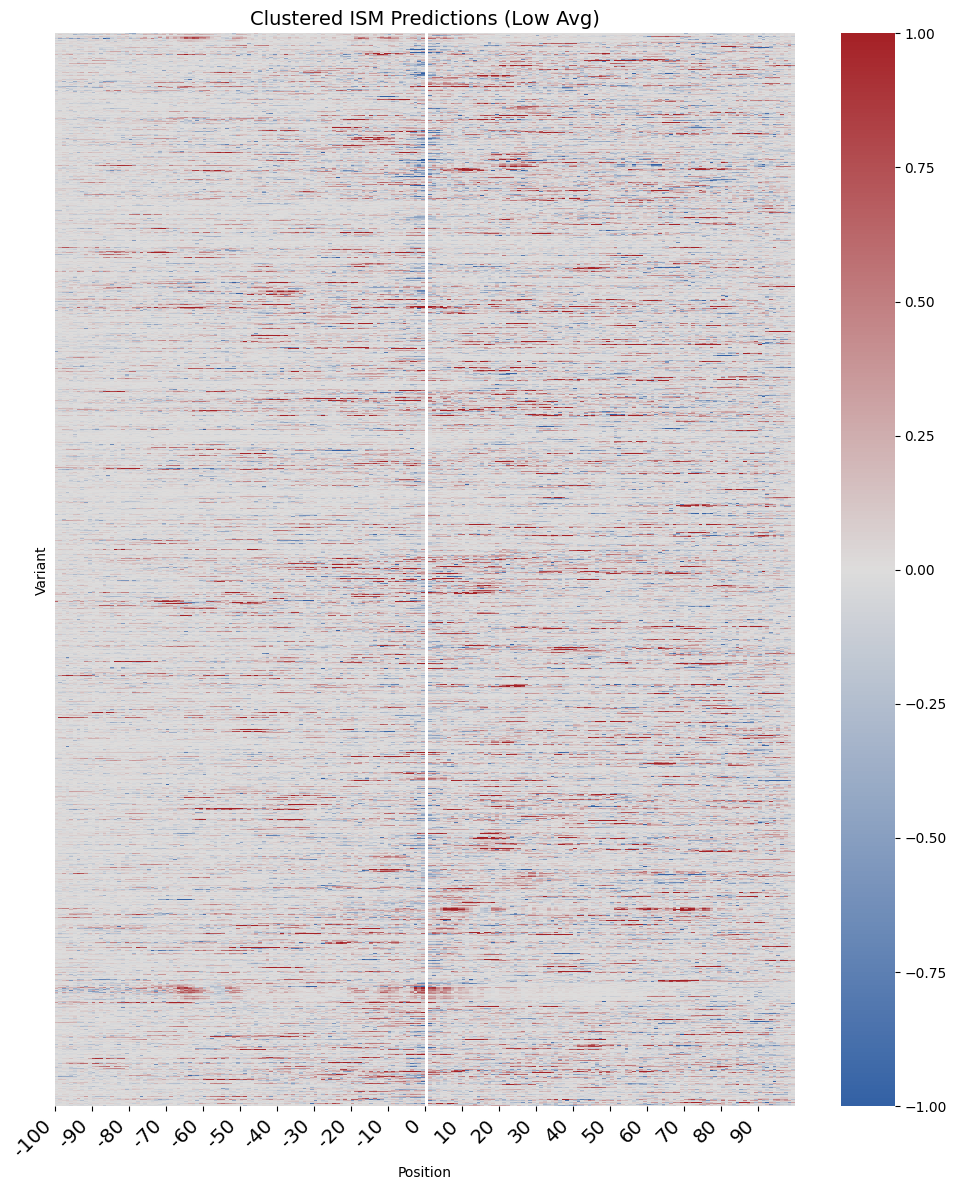

In [6]:
heatmap_array = low_array[row_order]

# --- Mask the 99th position (0-based = 100th) ---
mask = np.zeros_like(heatmap_array, dtype=bool)
if heatmap_array.shape[1] > 99:
    mask[:, 100] = True

# --- Shared color scale ---
heatmap_array = np.clip(heatmap_array, -1, 1)
vmin, vmax = -1, 1

coolwarm = plt.cm.coolwarm
mid_grey = coolwarm(0.5)
white_pos = abs(vmin) / (vmax - vmin)  # normalize position of white center (usually 0)
colors = [
    (0, "#3361A5"),        # dark blue at min
    (white_pos, mid_grey), # white at 0
    (1.0, "#A52126")        # dark red at max
]
custom_cmap = LinearSegmentedColormap.from_list("blue_white_red", colors)

# --- Plot ---
plt.figure(figsize=(10, 12))
sns.heatmap(
    heatmap_array,
    cmap=custom_cmap,
    center=0,
    vmin=vmin,
    vmax=vmax,
    xticklabels=10,
    yticklabels="",
    mask=mask,
    cbar=True
)

plt.title("Clustered ISM Predictions (Low Avg)", fontsize=14)
plt.xlabel("Position")
plt.ylabel("Variant")
plt.xticks(tick_positions, tick_labels, rotation=45, ha="right", fontsize=14)
plt.tight_layout()
plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/6-ism_variant_effects/delta_ism_low.png", dpi=1200)

plt.show()


### Plot a few of the ISM

/tmp/ipykernel_1306780/729034315.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(int(x + 0)) for x in xticks])


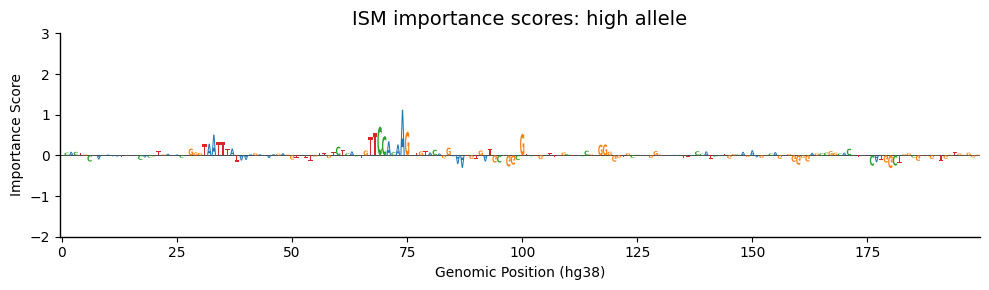

In [7]:
# Plot logo
import os
import logomaker

#### Plot for a single sequence ####
def plot_ism_logo_single(seq, scores, seq_id, save_path=None):
    color_scheme = {
        'A': '#1f77b4',
        'C': '#2ca02c',
        'G': '#ff7f0e',
        'T': '#d62728',
    }

    trimmed_seq = seq
    trimmed_scores = scores

    df = pd.DataFrame(0.0, index=range(len(trimmed_seq)), columns=["A", "C", "G", "T"])
    for i, base in enumerate(trimmed_seq):
        df.at[i, base] = trimmed_scores[i]

    fig, ax = plt.subplots(figsize=(10, 3))

    logo = logomaker.Logo(df, ax=ax, color_scheme=color_scheme)
    logo.style_spines(visible=False)
    logo.style_spines(spines=['left', 'bottom'], visible=True)

    ax.set_title(f"ISM importance scores: {seq_id}", fontsize=14)
    ax.set_xlabel("Genomic Position (hg38)")
    ax.set_ylabel("Importance Score")
    ax.set_ylim(-2, 3)

    # Genomic coordinate offset
    xticks = ax.get_xticks()
    ax.set_xticklabels([str(int(x + 0)) for x in xticks])

    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, format="svg")

    plt.show()

filtered_variants_reordered = filtered_variants.iloc[row_order]

sequence = filtered_variants.iloc[2680]["ref_seq"]

heatmap_array = high_array[row_order]
ism_scores = heatmap_array[2680]
seq_id = "high allele"
outdir = "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/6-ism_variant_effects/OT_ism"
plot_ism_logo_single(sequence, ism_scores, seq_id,
                     save_path=f"{outdir}/{seq_id}_ISM_logo.svg")

/tmp/ipykernel_1306780/3415807947.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(int(x + 0)) for x in xticks])


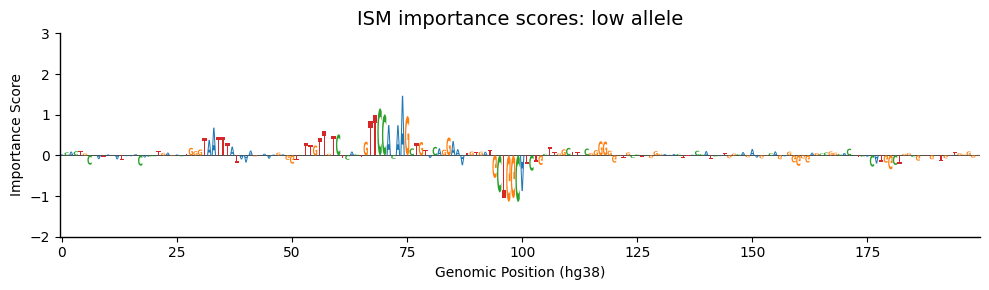

In [8]:
# Plot logo
import os
import logomaker

#### Plot for a single sequence ####
def plot_ism_logo_single(seq, scores, seq_id, save_path=None):
    color_scheme = {
        'A': '#1f77b4',
        'C': '#2ca02c',
        'G': '#ff7f0e',
        'T': '#d62728',
    }

    trimmed_seq = seq
    trimmed_scores = scores

    df = pd.DataFrame(0.0, index=range(len(trimmed_seq)), columns=["A", "C", "G", "T"])
    for i, base in enumerate(trimmed_seq):
        df.at[i, base] = trimmed_scores[i]

    fig, ax = plt.subplots(figsize=(10, 3))

    logo = logomaker.Logo(df, ax=ax, color_scheme=color_scheme)
    logo.style_spines(visible=False)
    logo.style_spines(spines=['left', 'bottom'], visible=True)

    ax.set_title(f"ISM importance scores: {seq_id}", fontsize=14)
    ax.set_xlabel("Genomic Position (hg38)")
    ax.set_ylabel("Importance Score")
    ax.set_ylim(-2, 3)

    # Genomic coordinate offset
    xticks = ax.get_xticks()
    ax.set_xticklabels([str(int(x + 0)) for x in xticks])

    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, format="svg")

    plt.show()

filtered_variants_reordered = filtered_variants.iloc[row_order]

sequence = filtered_variants.iloc[2680]["alt_seq"]

heatmap_array = low_array[row_order]
ism_scores = heatmap_array[2680]
seq_id = "low allele"
outdir = "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/6-ism_variant_effects/OT_ism"
plot_ism_logo_single(sequence, ism_scores, seq_id,
                     save_path=f"{outdir}/{seq_id}_ISM_logo.svg")